In [ ]:
#data preprocessing
import pandas as pd
df=pd.read_csv('../1_processed_data/Cynthia Wong Streaming History 2024-2025.csv')
df

In [183]:
unique_reasons = df['reason_end'].unique()

print("reason_end only label:")
print(unique_reasons)

reason_end only label:
['endplay' 'trackdone' 'logout' 'unexpected-exit-while-paused' 'remote'
 'backbtn' 'fwdbtn' 'unexpected-exit' 'trackerror']


In [184]:
reason_end_mapping = {reason: idx for idx, reason in enumerate(unique_reasons)}

print("set:")
print(reason_end_mapping)

df['reason_end'] = df['reason_end'].map(reason_end_mapping)
df

set:
{'endplay': 0, 'trackdone': 1, 'logout': 2, 'unexpected-exit-while-paused': 3, 'remote': 4, 'backbtn': 5, 'fwdbtn': 6, 'unexpected-exit': 7, 'trackerror': 8}


,ts,platform,min_played,conn_country,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,reason_start,reason_end,shuffle,skipped
0,2024-09-17,windows,0.01,CN,Rockstar Made,Playboi Carti,Whole Lotta Red,playbtn,0,False,True
1,2024-09-17,windows,0.06,CN,Ocho Rios,Daniel Caesar,NEVER ENOUGH,playbtn,0,False,True
2,2024-09-17,windows,3.22,CN,Always,Daniel Caesar,NEVER ENOUGH,clickrow,1,False,False
3,2024-09-17,windows,2.72,CN,Cool,Daniel Caesar,NEVER ENOUGH,trackdone,2,False,False
4,2024-09-19,ios,0.02,CN,和每天講再見,Gin Lee,和每天講再見,clickrow,3,False,False
...,...,...,...,...,...,...,...,...,...,...,...
4619,2025-05-21,windows,0.94,CN,SOMETHING ABOUT YOU,PARTYNEXTDOOR,$ome $exy $ongs 4 U,trackdone,3,False,False
4620,2025-05-22,ios,0.00,US,月光,THOME,KILL THOME II,clickrow,3,False,False
4621,2025-05-22,ios,0.03,US,CITY OF GOD,DONDA,DONDA 2,clickrow,0,False,True
4622,2025-05-22,ios,1.92,US,BURN EVERYTHING,DONDA,DONDA 2,clickrow,0,False,True


In [185]:
df['platform'] = df['platform'].map({'ios': 0, 'windows': 1})
df

,ts,platform,min_played,conn_country,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,reason_start,reason_end,shuffle,skipped
0,2024-09-17,1,0.01,CN,Rockstar Made,Playboi Carti,Whole Lotta Red,playbtn,0,False,True
1,2024-09-17,1,0.06,CN,Ocho Rios,Daniel Caesar,NEVER ENOUGH,playbtn,0,False,True
2,2024-09-17,1,3.22,CN,Always,Daniel Caesar,NEVER ENOUGH,clickrow,1,False,False
3,2024-09-17,1,2.72,CN,Cool,Daniel Caesar,NEVER ENOUGH,trackdone,2,False,False
4,2024-09-19,0,0.02,CN,和每天講再見,Gin Lee,和每天講再見,clickrow,3,False,False
...,...,...,...,...,...,...,...,...,...,...,...
4619,2025-05-21,1,0.94,CN,SOMETHING ABOUT YOU,PARTYNEXTDOOR,$ome $exy $ongs 4 U,trackdone,3,False,False
4620,2025-05-22,0,0.00,US,月光,THOME,KILL THOME II,clickrow,3,False,False
4621,2025-05-22,0,0.03,US,CITY OF GOD,DONDA,DONDA 2,clickrow,0,False,True
4622,2025-05-22,0,1.92,US,BURN EVERYTHING,DONDA,DONDA 2,clickrow,0,False,True


In [186]:
df['shuffle'] = df['shuffle'].astype(int)
df['skipped'] = df['skipped'].astype(int)
df

,ts,platform,min_played,conn_country,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,reason_start,reason_end,shuffle,skipped
0,2024-09-17,1,0.01,CN,Rockstar Made,Playboi Carti,Whole Lotta Red,playbtn,0,0,1
1,2024-09-17,1,0.06,CN,Ocho Rios,Daniel Caesar,NEVER ENOUGH,playbtn,0,0,1
2,2024-09-17,1,3.22,CN,Always,Daniel Caesar,NEVER ENOUGH,clickrow,1,0,0
3,2024-09-17,1,2.72,CN,Cool,Daniel Caesar,NEVER ENOUGH,trackdone,2,0,0
4,2024-09-19,0,0.02,CN,和每天講再見,Gin Lee,和每天講再見,clickrow,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...
4619,2025-05-21,1,0.94,CN,SOMETHING ABOUT YOU,PARTYNEXTDOOR,$ome $exy $ongs 4 U,trackdone,3,0,0
4620,2025-05-22,0,0.00,US,月光,THOME,KILL THOME II,clickrow,3,0,0
4621,2025-05-22,0,0.03,US,CITY OF GOD,DONDA,DONDA 2,clickrow,0,0,1
4622,2025-05-22,0,1.92,US,BURN EVERYTHING,DONDA,DONDA 2,clickrow,0,0,1


#Binary Classification

In [187]:
#define train&test
import pandas as pd
from sklearn.model_selection import train_test_split
features=[ 'min_played', 'shuffle']
X=df[features]
y=df['skipped']

# Split into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y 
)

# Print the shapes to verify
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Training features shape: (3236, 2)
Testing features shape: (1388, 2)
Training target shape: (3236,)
Testing target shape: (1388,)


In [188]:
# Import necessary libraries
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Create KNN classifier with 6 neighbors
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model using the training sets
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [189]:
# Make predictions on the test set
y_pred = knn.predict(X_test)

In [190]:
# Import necessary libraries
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

# Evaluate the model
print("Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}\n")

Model Evaluation:
Accuracy: 0.80



In [191]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

Confusion Matrix:
[[485 122]
 [161 620]]
Accuracy: 0.80
Precision: 0.84
Recall: 0.79


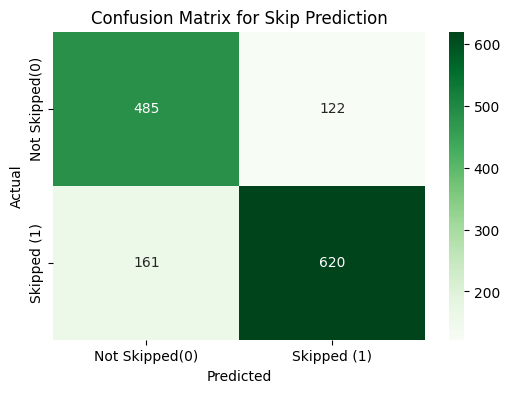

In [192]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Not Skipped(0)', 'Skipped (1)'], 
            yticklabels=['Not Skipped(0)', 'Skipped (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Skip Prediction')
plt.show()

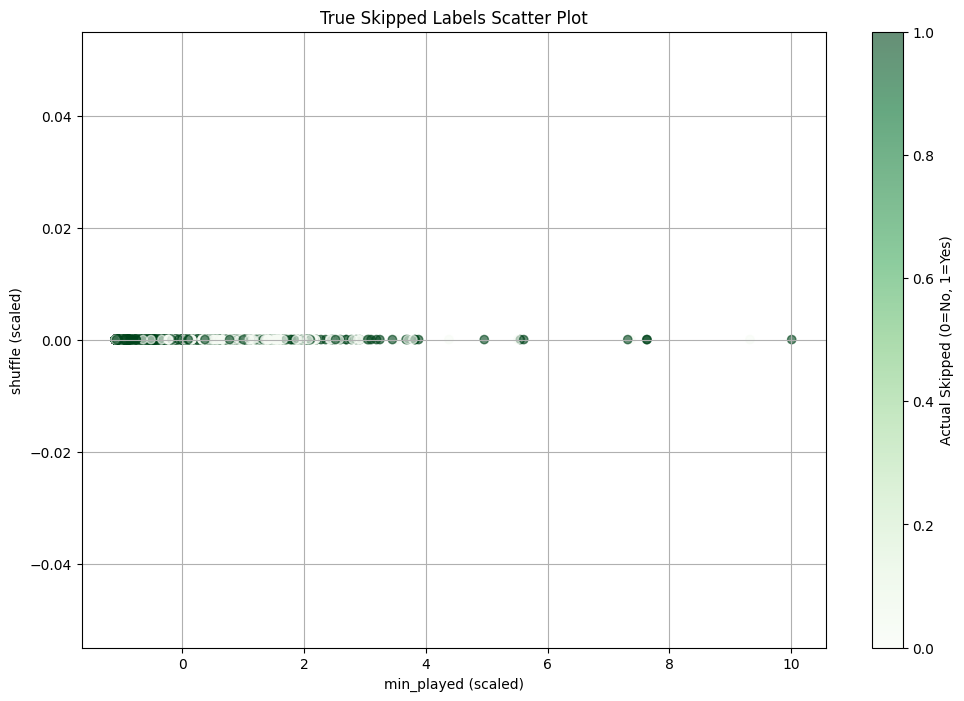

In [193]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

plt.figure(figsize=(12,8))
scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, cmap='Greens', alpha=0.6)

plt.xlabel('min_played (scaled)')
plt.ylabel('shuffle (scaled)')
plt.title('True Skipped Labels Scatter Plot')
plt.colorbar(scatter, label='Actual Skipped (0=No, 1=Yes)')
plt.grid(True)
plt.show()

The figure reflects when（shuffle=0），the relationship between'min_played'&'skipped'
Lighter-colored areas (toward the left) mean shorter play time with more no-skip cases, while darker -colored areas (toward the right) mean longer play time with more skip cases.

Playback duration and skipping behavior: There is a significant negative correlation, indicating that the longer the playback duration, the less likely users are to skip content.
Platform type and skipping behavior: There is almost no correlation, meaning the frequency of skipping behavior doesn't significantly differ between iOS and Windows platforms.
Playback duration and platform type: There is no significant correlation between these two, suggesting a similar distribution of playback durations across different platforms.

In [194]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

#Multiclass Classification

Random Forest

In [195]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

In [196]:
features = ['min_played', 'skipped', 'platform']
X = df[features]
y = df['reason_end']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [197]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [207]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

target_names = [
    'endplay',
    'trackdone',
    'logout',
    'unexpected-exit-while-paused',
    'remote',
    'backbtn',
    'fwdbtn',
    'unexpected-exit',
    'trackerror'
]

# report
print("report：\n")
print(classification_report(
    y_test,
    y_pred,
    labels=range(len(target_names)),  # 0-8
    target_names=target_names,
    zero_division=0                   # 防止除以0时报错
))

report：

                              precision    recall  f1-score   support

                     endplay       0.85      0.98      0.91       663
                   trackdone       0.91      0.98      0.95       501
                      logout       0.00      0.00      0.00        13
unexpected-exit-while-paused       0.73      0.47      0.57        79
                      remote       0.40      0.36      0.38        11
                     backbtn       0.00      0.00      0.00        42
                      fwdbtn       0.18      0.03      0.04        78
             unexpected-exit       0.00      0.00      0.00         0
                  trackerror       1.00      1.00      1.00         1

                    accuracy                           0.85      1388
                   macro avg       0.45      0.42      0.43      1388
                weighted avg       0.79      0.85      0.81      1388



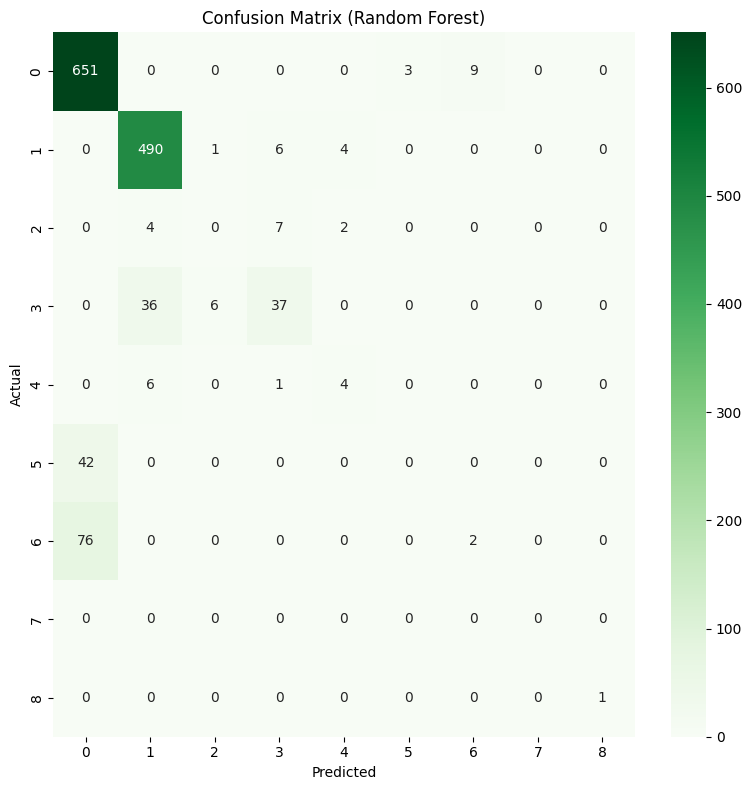

In [177]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred, labels=all_labels)

plt.figure(figsize=(8, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix (Random Forest)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [161]:
# 定义特征和目标变量
X = df[['min_played', 'platform', 'shuffle']]
y = df['reason_end']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# 检查训练集和测试集的类别分布
print("训练集类别分布:")
print(y_train.value_counts())

print("\n测试集类别分布:")
print(y_test.value_counts())

knn = KNeighborsClassifier(n_neighbors=4)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

训练集类别分布:
reason_end
0    1341
1     999
6     158
3     138
5      67
2      36
4      32
7       2
8       1
Name: count, dtype: int64

测试集类别分布:
reason_end
0    887
1    666
3    109
6     96
5     53
2     22
4     16
8      1
Name: count, dtype: int64


In [162]:
knn = KNeighborsClassifier(n_neighbors=6)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=6)

In [163]:
y_pred = knn.predict(X_test_scaled)

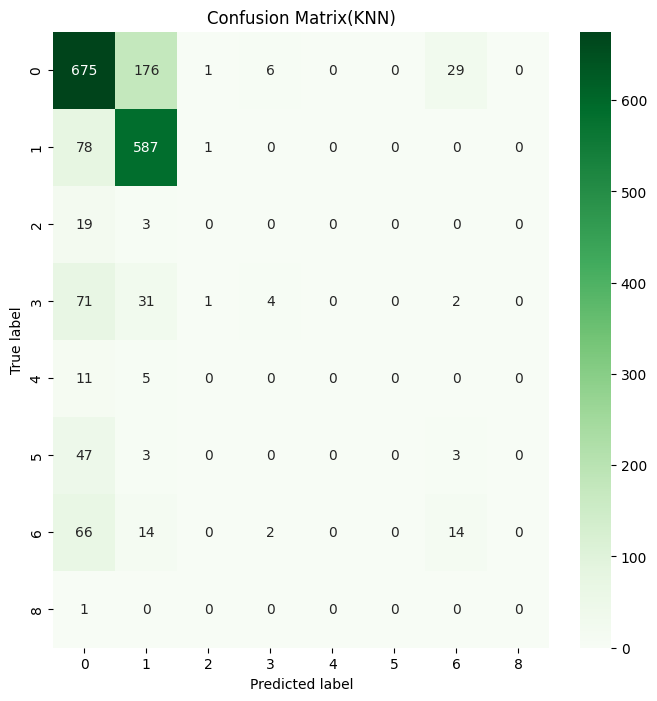

In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 获取目标变量中的唯一类别
unique_reasons = np.unique(y_test)

# 计算混淆矩阵
cm = confusion_matrix(y_test, y_pred, labels=unique_reasons)

# 创建 DataFrame
cm_df = pd.DataFrame(cm, index=unique_reasons, columns=unique_reasons)

# 可视化混淆矩阵
plt.figure(figsize=(8, 8))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix(KNN)')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

In [165]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.69
Precision: 0.63
Recall: 0.69
F1 Score: 0.65


#AB test
#different platform(iOS vs Windows)

   platform  mean_min_played  median_min_played  count  skip_rate
0         0         1.703984              1.620   3582   0.570352
1         1         1.950240              2.005   1042   0.536468


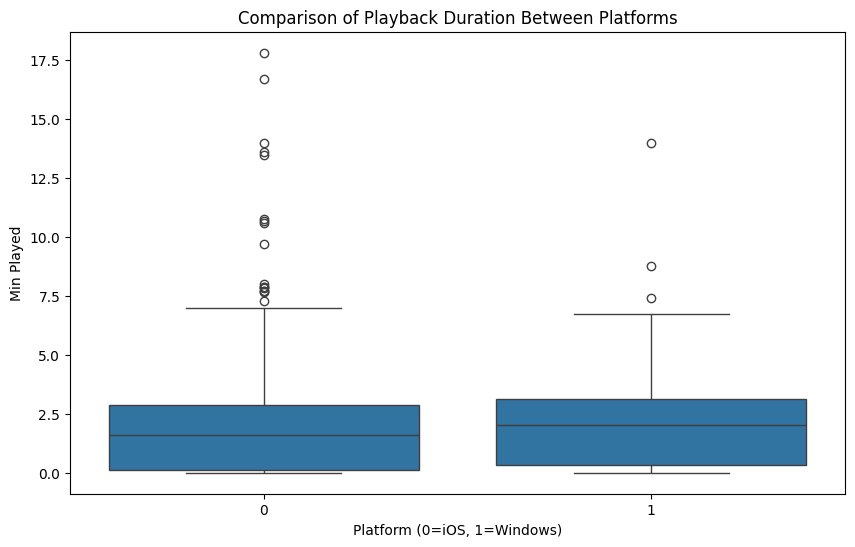

In [166]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


# 计算每个平台的播放时长和跳过率
platform_data = df.groupby('platform').agg({
    'min_played': ['mean', 'median', 'count'],
    'skipped': 'mean'
}).reset_index()
platform_data.columns = ['platform', 'mean_min_played', 'median_min_played', 'count', 'skip_rate']

print(platform_data)

plt.figure(figsize=(10, 6))
sns.boxplot(x='platform', y='min_played', data=df)
plt.xlabel('Platform (0=iOS, 1=Windows)')
plt.ylabel('Min Played')
plt.title('Comparison of Playback Duration Between Platforms')
plt.show()

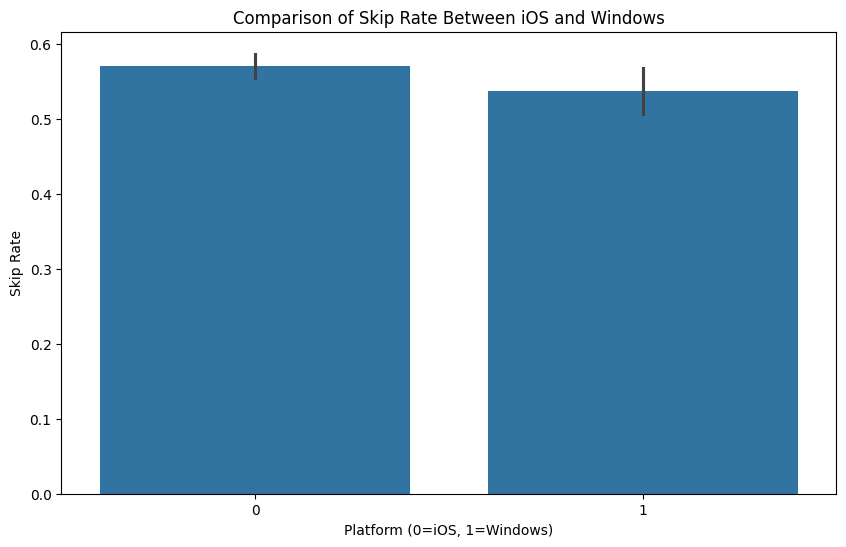

T-test for playback duration: t-statistic = -4.367492022693014, p-value = 1.284318081050278e-05
Chi-square test for skip rate: chi2 = 3.6297064729893322, p-value = 0.056756825726778565


In [167]:
# 绘制跳过率的比较图
plt.figure(figsize=(10, 6))
sns.barplot(x='platform', y='skipped', data=df)
plt.xlabel('Platform (0=iOS, 1=Windows)')
plt.ylabel('Skip Rate')
plt.title('Comparison of Skip Rate Between iOS and Windows')
plt.show()

# 统计检验：播放时长的t检验
t_stat, p_value = stats.ttest_ind(
    df[df['platform'] == 0]['min_played'],
    df[df['platform'] == 1]['min_played']
)
print(f"T-test for playback duration: t-statistic = {t_stat}, p-value = {p_value}")

# 统计检验：跳过率的卡方检验
contingency_table = pd.crosstab(df['platform'], df['skipped'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-square test for skip rate: chi2 = {chi2}, p-value = {p_value}")

Regression

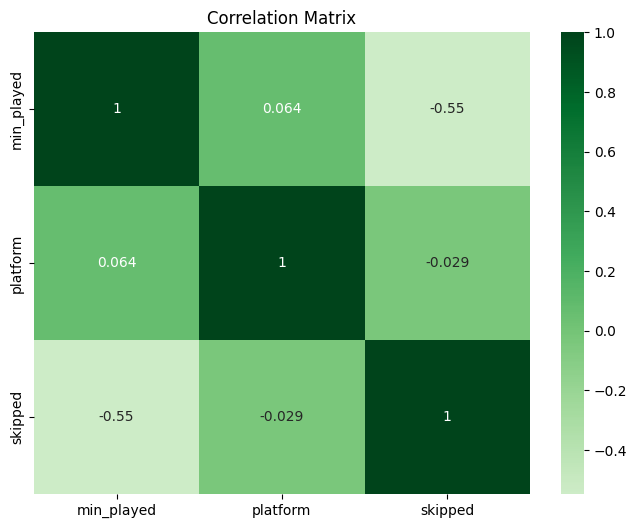

Feature Correlation with Target:
min_played   -0.547924
platform     -0.028539
dtype: float64


In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = df[['min_played', 'platform', 'skipped']].corr()

# heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='Greens', center=0)
plt.title('Correlation Matrix')
plt.show()

feature_correlation = df[['min_played', 'platform']].apply(lambda x: x.corr(df['skipped']))

print("Feature Correlation with Target:")
print(feature_correlation)